In [1]:
import os
from collections import namedtuple
from itertools import batched, chain
import json
import math
from multiprocessing import Pool
from pathlib import Path

from datasets import load_from_disk
import matplotlib.pyplot as plt
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import sys
import os
# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.detectors.ppmd import PPMdDetector
from genai_detection.detectors.unmasking import UnmaskingDetector

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica, sans-serif'
plt.rcParams['font.size'] = 6.5
plt.rcParams['lines.linewidth'] = .5
plt.rcParams['axes.linewidth'] = .5
plt.rcParams['grid.linewidth'] = .25

In [3]:
from concurrent.futures import ThreadPoolExecutor


bytepair_tokenizer = AutoTokenizer.from_pretrained('gpt2', truncation=False, max_length=None, model_max_length=None)


def tokenize_bytepair(text):
    return bytepair_tokenizer.tokenize(text)


def normalize_text(text):
    stemmer = SnowballStemmer('english')
    return ' '.join(stemmer.stem(w) for w in text.lower().split())


def sample_texts(h, m, min_text_ln=3000, n_texts=30, seed=42):
    h = h.query('text.str.len() >= @min_text_ln')
    h = h.sample(n=min(h['id'].count(), n_texts), random_state=seed)

    m = {k: v.query('text.str.len() >= @min_text_ln') for k, v in m.items()}
    m = {k: v.sample(n=min(n_texts, v['id'].count()), random_state=seed) for k, v in m.items()}

    return h, m

def _label_curve_pairings(curves, pairing_label):
    curves = pd.DataFrame({f'{pairing_label} ({i:04})': c for i, c in enumerate(curves)})
    curves['pairing'] = pairing_label
    return curves

def unmask(text_pairs, **unmask_kwargs):
    # text_pairs is list of pairs, but get_scores expects list of texts and batches them
    pairs = text_pairs['pair']  # Assuming this is a list of (text1, text2) tuples
    print(len(pairs), 'pairs to unmask')

    def compute_score(pair):
        unmask_det = UnmaskingDetector(**unmask_kwargs)
        return unmask_det.get_curves(pair)

    with ThreadPoolExecutor() as executor:
        curves = list(executor.map(compute_score, pairs))

    return curves

def old_unmask(texts_h, texts_m, **unmasking_kwargs):
    unmask_det = UnmaskingDetector(strict=True, **unmasking_kwargs)

    with Pool() as pool:
        th = texts_h['text'].map(normalize_text)
        th = th.iloc[:len(th) // 2 * 2]     # Ensure rows are a multiple of two
        l = 'Human / Human'
        curves_h = tqdm(pool.imap(unmask_det.get_curves, batched(th, n=2)), desc=f'Unmasking {l}', total=len(th) // 2)
        curves_h = _label_curve_pairings(np.squeeze(list(curves_h), axis=1), 'Human / Human')

        curves_m = []
        curves_hm = []
        machine_names = list(texts_m.keys())
        for i, tm in enumerate(texts_m.values()):
            tm = tm['text'].map(normalize_text).iloc[:len(tm) // 2 * 2]
            l = f'{machine_names[i]} / {machine_names[i]}'
            cm = list(tqdm(pool.imap(unmask_det.get_curves, batched(tm, n=2)), desc=f'Unmasking {l}', total=len(tm) // 2))
            curves_m.append(_label_curve_pairings(np.squeeze(list(cm), axis=1), l))

            n = min(len(th), len(tm)) // 2
            l = f'Human / {machine_names[i]}'
            it = zip(th[:n], tm[:n])
            chm = list(tqdm(pool.imap(unmask_det.get_curves, it), desc=f'Unmasking {l}', total=n))
            curves_hm.append(_label_curve_pairings(np.squeeze(list(chm), axis=1), l))

        curves = pd.concat([curves_h, *curves_m, *curves_hm])
        display(curves)
        curves = pd.melt(curves, var_name='curve_id', value_name='accuracy', id_vars=['pairing'], ignore_index=False)
        display(curves)
        curves = curves.reset_index(drop=False, names='round')
        display(curves)
    return curves


def compress(texts_h, texts_m):
    comp_det = PPMdDetector()

    scores = [('Human / Human', s) for s in comp_det.get_score(tqdm(texts_h['text'], desc='Compressing Human / Human'))]

    machine_names = list(texts_m.keys())
    for i, tm in enumerate(texts_m.values()):
        l = f'{machine_names[i]} / {machine_names[i]}'
        it = tqdm(texts_m[machine_names[i]]['text'], desc=f'Compressing {l}')
        scores.extend([(l, s) for s in comp_det.get_score(it)])

        l = f'Human / {machine_names[i]}'
        n = min(len(texts_h['text']), len(tm)) // 2
        it = chain(*zip(texts_h['text'][:n].map(normalize_text), tm['text'][:n].map(normalize_text)))
        it = tqdm(it, desc=f'Compressing {l}', total=n * 2)
        scores.extend([(l, s) for s in comp_det.get_score(it)])

    return pd.DataFrame(scores, columns=['pairing', 'score'])

def plot_unmasking_curves(curves, targets, savefig=None, dataset_name:str=None):
    pal = sns.color_palette('husl', 2) 

    seen_labels = set()
    for c,l in zip(curves, targets):
        if len(c) == 0:
            continue
        c = c[0].tolist()
        label = None
        if l not in seen_labels:
            label = f"Same Author: {l}"
            seen_labels.add(l)
        plt.plot(c, color=pal[l], label=label)

    plt.xlabel('Unmasking Rounds')
    title = f'Unmasking Curves for {dataset_name}' if dataset_name else 'Unmasking Curves'
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout(pad=0.8)
    plt.subplots_adjust(wspace=.025, hspace=.05)
    if savefig:
        Path(savefig).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(savefig)
    plt.show()

def old_plot_unmasking_curves(curves, max_cols=4, errorbar=('ci', 95), savefig=None):
    machines = [m.split(' / ', 1)[0] for m in curves['pairing'].unique() if 'Human' not in m]
    n_cols = min(max_cols, len(machines))
    n_rows = int(math.ceil(len(machines) / max_cols))
    pal = sns.color_palette('husl', 3)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(1.7 * n_cols, n_rows * 1.45), sharex=True, sharey=True)

    for i in range(n_cols * n_rows):
        ax = axs.flat[i]
        if i < len(machines):
            p = ['Human / Human', f'{machines[i]} / {machines[i]}', f'Human / {machines[i]}']
            _ = p   # Mark used
            c = curves.query('pairing in @p')
            sns.lineplot(c, x='round', y='accuracy', hue='pairing', style='pairing', palette=pal, errorbar=errorbar, ax=ax)
            ax.legend(title=None, frameon=False, borderaxespad=.15)
        ax.set_ylim((.5, 1.0))
        ax.set_xlim((0, curves['round'].max()))
        ax.set_xlabel('Unmasking Rounds')
        if i % max_cols == 0:
            ax.set_ylabel('Accuracy')

    plt.tight_layout(pad=0.8)
    plt.subplots_adjust(wspace=.025, hspace=.05)
    if savefig:
        Path(savefig).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(savefig)
    plt.show()


def plot_compression(scores, max_cols=4, savefig=None):
    machines = [m.split(' / ', 1)[0] for m in scores['pairing'].unique() if 'Human' not in m]
    n_cols = min(max_cols, len(machines))
    n_rows = int(math.ceil(len(machines) / max_cols))
    pal = sns.color_palette('husl', 3)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(1.7 * n_cols, n_rows * 1.8), sharex=True, sharey=True)

    for i in range(n_cols * n_rows):
        ax = axs.flat[i]
        if i < len(machines):
            p = ['Human / Human', f'{machines[i]} / {machines[i]}', f'Human / {machines[i]}']
            for i_, p_ in enumerate(p):
                sns.kdeplot(scores.query('pairing == @p_')['score'], color=pal[i_], label=p_, ax=ax)
            ax.legend(p, title=None, frameon=False, borderaxespad=.15)
        ax.set_xlabel('CBC Score')
        if i % max_cols == 0:
            ax.set_ylabel('Density')

    plt.tight_layout(pad=0.8)
    plt.subplots_adjust(wspace=.025, hspace=.05)
    if savefig:
        Path(savefig).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(savefig)
    plt.show()


TTestResult = namedtuple('TTestResult', ['t', 'dof', 'p', 'd'])


def t_test(a, b):
    t, p = stats.ttest_ind(a, b)
    d = t * np.sqrt((len(a) + len(b)) / (len(a) * len(b)))
    return TTestResult(t=t, dof=len(a) + len(b) - 2, p=p, d=d)


def t_test_str(t: TTestResult, correction_factor=1):
    p_str = f'< {.001:>5}' if t.p < .001 else f'= {t.p:>5,.3f}'
    if correction_factor:
        p_corr = t.p * correction_factor
        if p_corr >= 1.:
            p_str += ', p[bf] = 1.00'
        else:
            p_str += ', p[bf] ' + (f'< {.001:>5}' if p_corr < .001 else f'= {p_corr:>5,.3f}')
    return f't({t.dof:,}) = {t.t:>6,.2f}, p {p_str.replace('0.', '.')}, d = {t.d:>4,.1f}'


def print_t_test_for_curves(curves, min_round=10):
    pairings = [p for p in curves['pairing'].unique() if not p.startswith('Human /')]
    print('Differences from Human / Human:')
    for pairing in pairings:
        t = t_test(curves.query('round >= @min_round and pairing == "Human / Human"')['accuracy'].dropna(),
                   curves.query('round >= @min_round and pairing == @pairing')['accuracy'].dropna())
        print(f'  {pairing:<{max(len(p_) for p_ in pairings) + 1}}: {t_test_str(t, len(pairings))}')


def print_t_test_for_compression(cbc):
    pairings = [p for p in cbc['pairing'].unique() if not p.startswith('Human /')]
    print('Differences from Human / Human:')
    for pairing in pairings:
        t = t_test(cbc.query('pairing == "Human / Human"')['score'],
                   cbc.query('pairing == @pairing')['score'])
        print(f'  {pairing:<{max(len(p_) for p_ in pairings) + 1}}: {t_test_str(t, len(pairings))}')

### Koppel Webis dataset (Gutenberg subset)

In [4]:
# ds_koppel = load_from_disk(os.path.join(os.path.abspath(".."), CONFIG.PATH2KOPPEL_WEBIS))['train'].to_pandas()
# targets = ds_koppel['same']

In [5]:
# curves = unmask(ds_koppel)

In [6]:
# sys.path.append(os.path.abspath(".."))
# plot_unmasking_curves(curves=curves, targets=targets, savefig=Path.cwd().parent / CONFIG.SAVE_PATH / 'unmasking_curves' / CONFIG.KOPPEL, dataset_name=CONFIG.KOPPEL)

### Blog dataset

In [7]:
ds_blog = load_from_disk(os.path.join(os.path.abspath(".."), CONFIG.PATH2BLOG))['train'].to_pandas()
targets = ds_blog['same']

In [8]:
ds_blog

,pair,authors,same
0,[ I would like to start out wi...,"[4269654, 4269654]",True
1,[ On the advice of author Hugh Hewitt I’m st...,"[3567093, 3567093]",True
2,[ Of Love and Coffee By: Marie...,"[3664499, 3664499]",True
3,[ By: Mariel G. Calalo My gr...,"[3664499, 3664499]",True
4,"[ Well, E3 is over and it was awesom...","[3293221, 3293221]",True
...,...,...,...
31267,[ I am just a simple girl. I an emotion...,"[4190254, 4190254]",True
31268,[ I want to consider myself a ...,"[4260903, 4260903]",True
31269,"[ Wow, I love fruit. I read t...","[4260903, 4260903]",True
31270,[ This is a little overview of the past ...,"[3337776, 3469195]",False


In [12]:
targets.value_counts()

same
True     31192
False       80
Name: count, dtype: int64

In [9]:
curves = unmask(ds_blog)

31272 pairs to unmask


/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_24765/3822923362.py:117: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(pad=0.8)
/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_24765/3822923362.py:121: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(savefig)
/Users/klara/Library/Caches/pypoetry/virtualenvs/generative-ai-detection-PkLo9Jli-py3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


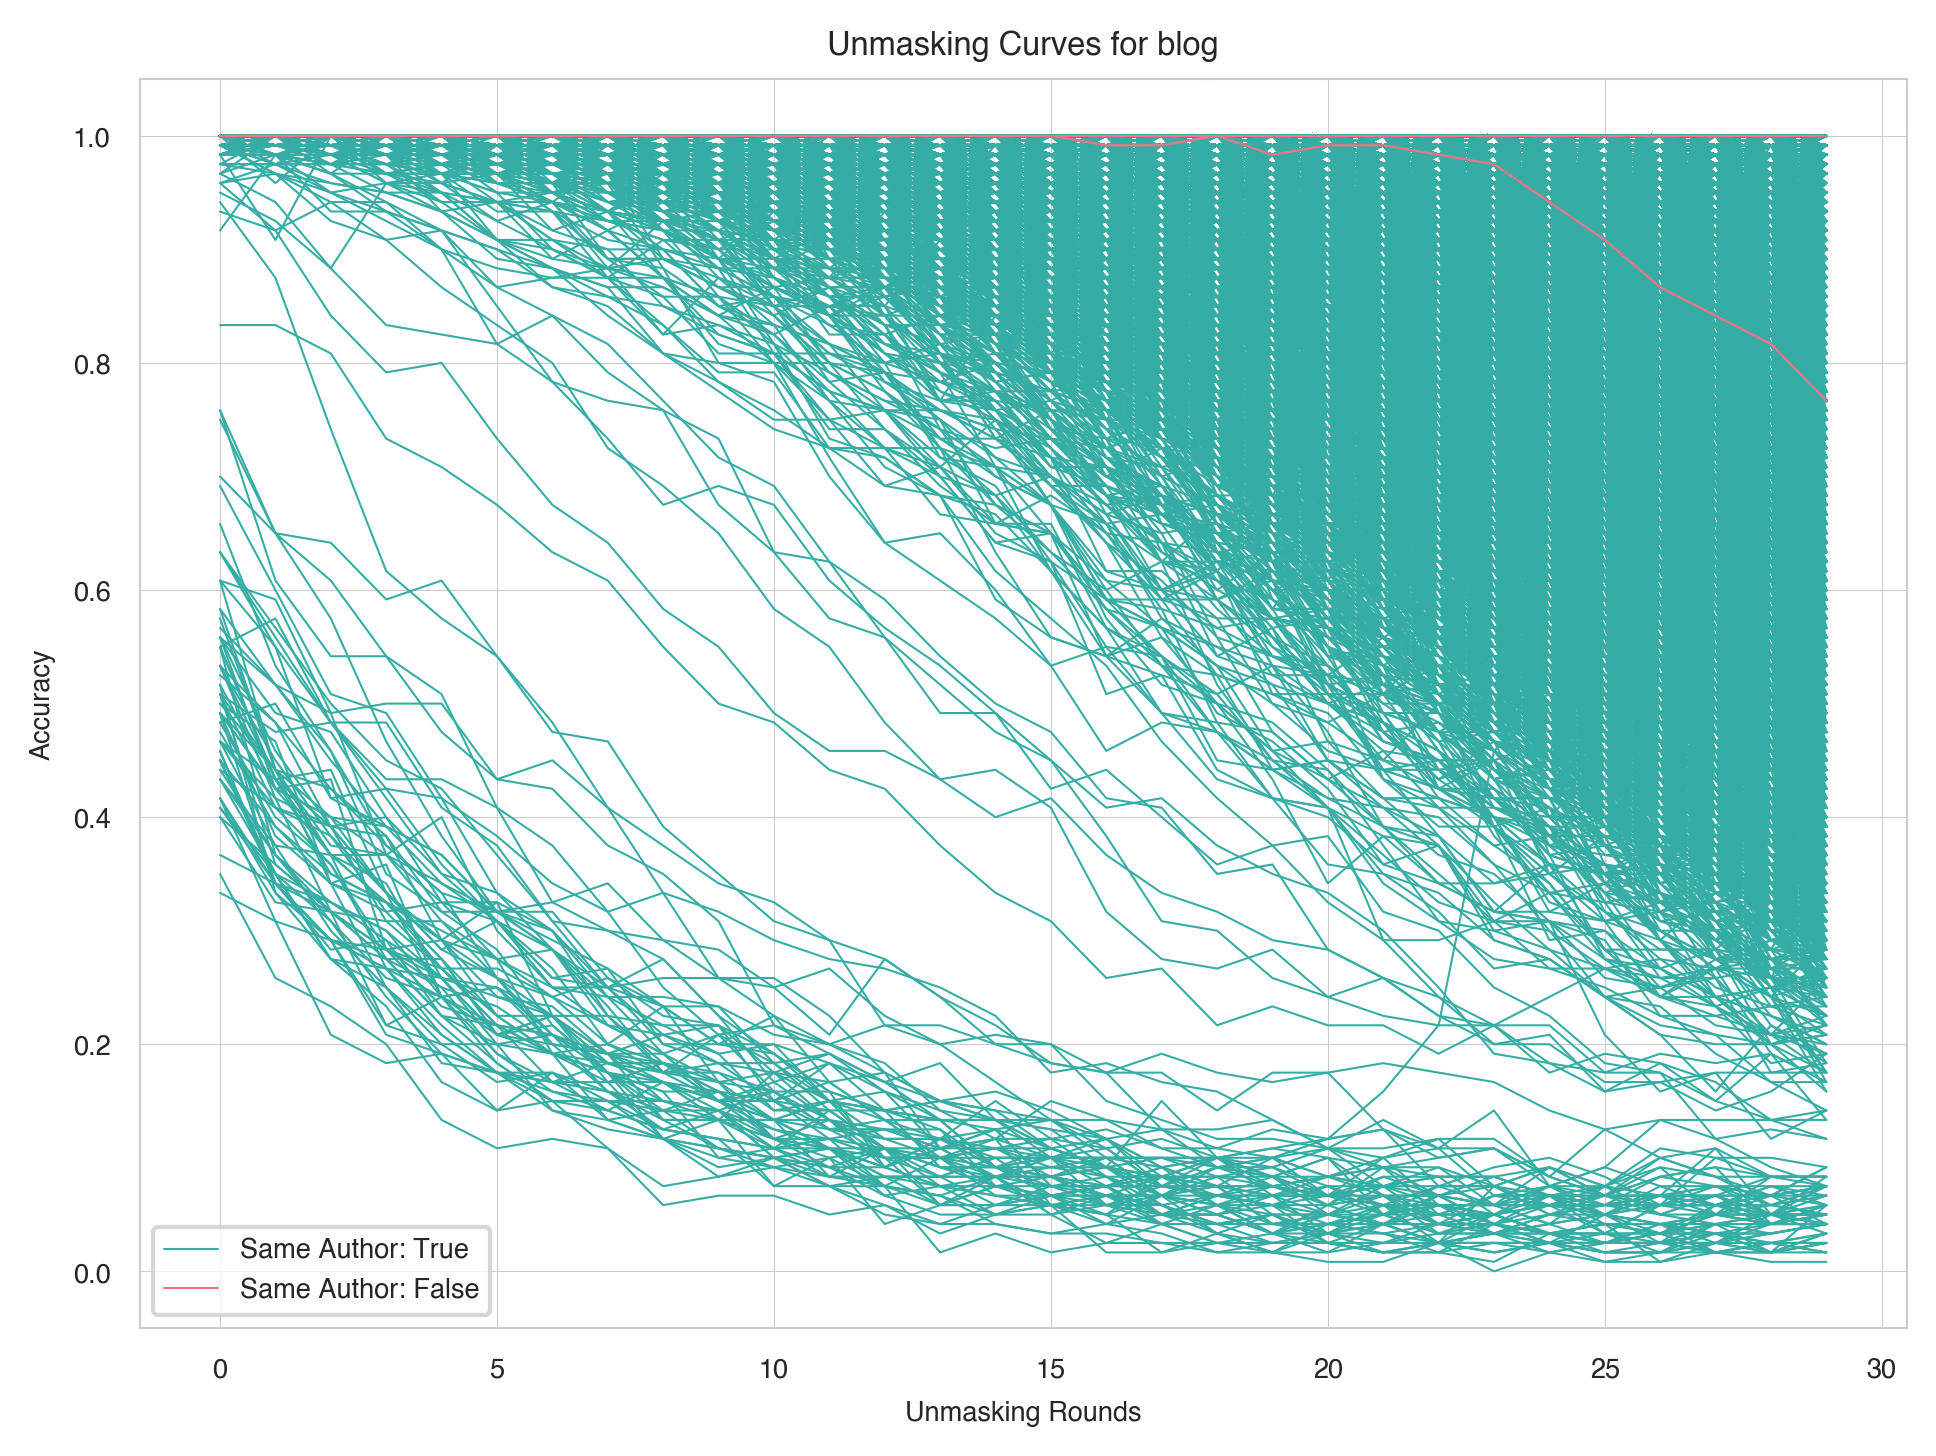

In [10]:
sys.path.append(os.path.abspath(".."))
plot_unmasking_curves(curves=curves, targets=targets, savefig=Path.cwd().parent / CONFIG.SAVE_PATH / 'unmasking_curves' / CONFIG.BLOG, dataset_name=CONFIG.BLOG)

### PAN

In [11]:
from collections import Counter


def split_pan_ds_dataset_by_model(df, seed=42):
    df_human = df.query('model == "human"').sample(frac=1, random_state=seed)
    df_machine = {
        # 'Llama2-7b': df.query('model == "llama-2-7b-chat"').sample(frac=1, random_state=seed),
        # 'Llama2-70b': df.query('model == "llama-2-70b-chat"').sample(frac=1, random_state=seed),
        # 'GPT-3': df.query('model == "gpt-3.5-turbo"').sample(frac=1, random_state=seed),
        # 'GPT-4o': df.query('model == "gpt-4o"').sample(frac=1, random_state=seed),
        'gpt-4-turbo-paraphrase': df.query('model == "gpt-4-turbo-paraphrase"').sample(frac=1, random_state=seed),
        'gemini-pro': df.query('model == "gemini-pro"').sample(frac=1, random_state=seed),
        'gpt-4-turbo': df.query('model == "gpt-4-turbo"').sample(frac=1, random_state=seed),
        'gemini-pro-paraphrase': df.query('model == "gemini-pro-paraphrase"').sample(frac=1, random_state=seed),
        # 'o1': df.query('model == "openai-o1"').sample(frac=1, random_state=seed),
    }
    return df_human, df_machine


# print(os.path.join(os.path.abspath(".."), CONFIG.PATH2PAN25))
ds_pan = load_from_disk(os.path.join(os.path.abspath(".."), CONFIG.PATH2PAN25))['train'].to_pandas()
# label is string 'human' for human texts, but we want to have it as 0
ds_pan['label'] = ds_pan['label'].map({'human': 0, 'machine': 1})
print('Unique Models:', list(ds_pan['model'].unique()))
df_pan_h, df_pan_m = split_pan_ds_dataset_by_model(ds_pan)


# print('number of human texts in PAN dataset:', len(df_pan_h))  
# print('number of machine texts in PAN dataset:', sum(len(v) for v in df_pan_m.values()))

# Expand gnews meta data
# tmp = []
# for i, r in df_pan_h.iterrows():
#     j = json.loads(r['gnews_meta'])
#     for k, v in j.items():
#         r[f'gnews_{k}'] = v
#     del r['gnews_meta']
#     tmp.append(r)
# df_pan_h = pd.DataFrame(tmp)
# del tmp

display(df_pan_h.head())
# label_counts = Counter(df_pan_h["label"])
# print("Label counts:", label_counts)

assert df_pan_h['label'].count() > 0 , "No human texts found in PAN dataset"
assert df_pan_h['label'].sum() == 0, "PAN dataset contains human texts with labelled as AI-generated"

sample_pan = sample_texts(df_pan_h, df_pan_m, n_texts=400)

Unique Models: ['human', 'gemini-pro-paraphrase', 'gpt-4-turbo-paraphrase', 'gemini-pro', 'gpt-4-turbo']


,id,text,label,model
746,news-2021-01-01-2021-12-31-kamalaharrisvicepre...,Kamala Harris to tell UN body it’s time to pre...,NaN,human
56,news-2021-01-01-2021-12-31-covid19/art-035,Classification of Omicron (B.1.1.529): SARS-Co...,NaN,human
684,news-2021-01-01-2021-12-31-cnnchriscuomo/art-017,Reports say CNN’s Chris Cuomo got special COVI...,NaN,human
896,news-2021-01-01-2021-12-31-colonialpipelinehac...,Colonial Pipeline ransomware attack highlights...,NaN,human
723,news-2021-01-01-2021-12-31-cnnchriscuomo/art-030,New York Gov. Andrew Cuomo will resign\n\nCNN ...,NaN,human


AssertionError: No human texts found in PAN dataset

In [ ]:
curves_pan_top_250 = old_unmask(*sample_pan, top_n=250, n_delete=4, rounds=25, shared_vocab_only=True)

In [ ]:
old_plot_unmasking_curves(curves_pan_top_250, errorbar=('pi', 50), savefig='../data/figures/unmasking-curves-pan-250.pdf')

In [ ]:
curves_pan_top_500 = old_unmask(*sample_pan, top_n=500, n_delete=8, rounds=25, shared_vocab_only=True)

In [ ]:
old_plot_unmasking_curves(curves_pan_top_500, errorbar=('pi', 50), savefig='../data/figures/unmasking-curves-pan-500.pdf')

In [ ]:
print_t_test_for_curves(curves_pan_top_500)

In [ ]:
cbc_pan = compress(*sample_pan)
plot_compression(cbc_pan, savefig='../data/figures/unmasking-compression-pan.pdf')

In [ ]:
print_t_test_for_compression(cbc_pan)